<a href="https://colab.research.google.com/github/Charlesphilip6/Charlesgeospatial/blob/main/lineament_and_fault_mapping_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rasterio geopandas shapely scikit-image scipy

**Import your Data **bold text**

In [ ]:
import rasterio
import numpy as np

dem_path = r"/content/output_SRTMGL1Ellip.tif"   # Upload your DEM file to Colab, then update this path if necessary
with rasterio.open(dem_path) as src:
    dem = src.read(1)
    transform = src.transform
    crs = src.crs

**Preprocessing DEM Using Gaussin Filter**

In [ ]:
from scipy.ndimage import gaussian_filter

dem_smooth = gaussian_filter(dem, sigma=1)  # sigma=1 ≈ kernel size 3x3


**Edge Detection Using Sobel**

In [ ]:
from skimage.filters import sobel

edges = sobel(dem_smooth)
binary_edges = (edges > 0.2).astype(np.uint8)  # threshold


**Geometry Import Shapely**

In [ ]:
from shapely.geometry import LineString
import geopandas as gpd
import numpy as np
from skimage.feature import canny # New import for Canny
from skimage.morphology import skeletonize # New import for skeletonization

# Step 1: Apply Canny edge detection (instead of Sobel + simple threshold)
# Canny is more robust to noise and produces thinner edges.
# sigma: standard deviation of the Gaussian filter before edge detection.
# low_threshold, high_threshold: for hysteresis thresholding.
# These parameters are crucial for tuning and can be adjusted.
canny_edges = canny(dem_smooth, sigma=2, low_threshold=0.1, high_threshold=0.5) # Tuned values for less noise

# Step 2: Skeletonize the Canny edges to get single-pixel wide lines
# This reduces detected edges to their topological skeletons, which are ideal for vectorization.
skeleton = skeletonize(canny_edges)

lines = []
rows, cols = skeleton.shape

# Helper function to trace lines from a skeletonized image using BFS
# This function extracts connected components of pixels and forms LineString objects.
# Note: For complex branched structures, this simple BFS will create one LineString
# for the entire connected component, rather than distinct branches. If precise branch
# separation is needed, more advanced graph-based methods would be required.
def trace_skeleton_lines_bfs(skeleton_image, transform, min_line_length_pixels=10):
    traced_lines = []
    rows, cols = skeleton_image.shape
    visited = np.zeros_like(skeleton_image, dtype=bool)

    # Directions for 8-connectivity (all neighbors including diagonals)
    dr = [-1, -1, -1, 0, 0, 1, 1, 1]
    dc = [-1, 0, 1, -1, 1, -1, 0, 1]

    for r_start in range(rows):
        for c_start in range(cols):
            if skeleton_image[r_start, c_start] and not visited[r_start, c_start]:
                current_path_pixels = []
                queue = [(r_start, c_start)]
                visited[r_start, c_start] = True

                head = 0 # Manually manage queue index for potentially better performance with Python lists
                while head < len(queue):
                    pr, pc = queue[head]
                    head += 1

                    current_path_pixels.append((pc, pr)) # Store as (col, row) for transform

                    for i in range(8):
                        nr, nc = pr + dr[i], pc + dc[i]

                        # Check bounds and if it's an unvisited skeleton pixel
                        if 0 <= nr < rows and 0 <= nc < cols and \
                           skeleton_image[nr, nc] and not visited[nr, nc]:
                            visited[nr, nc] = True
                            queue.append((nr, nc))

                # Process the traced path if it's long enough
                if len(current_path_pixels) >= min_line_length_pixels:
                    # Convert pixel coordinates to geographic coordinates
                    geo_coords = []
                    for px, py in current_path_pixels:
                        gx, gy = transform * (px, py)
                        geo_coords.append((gx, gy))

                    # Ensure unique and sufficient points for LineString (remove consecutive duplicates)
                    unique_geo_coords = []
                    if geo_coords:
                        unique_geo_coords.append(geo_coords[0])
                        for coord in geo_coords[1:]:
                            if coord != unique_geo_coords[-1]:
                                unique_geo_coords.append(coord)

                    if len(unique_geo_coords) > 1: # LineString needs at least 2 distinct points
                        traced_lines.append(LineString(unique_geo_coords))

    return traced_lines

# Step 3: Trace lines from the skeletonized image
# min_line_length_pixels can be adjusted to filter out very short, noisy lines.
lines = trace_skeleton_lines_bfs(skeleton, transform, min_line_length_pixels=20) # You can tune this value

# Create the GeoDataFrame with the new set of lineaments
gdf = gpd.GeoDataFrame(geometry=lines, crs=crs)

**Projection Transformation**

**Azimuthal Orientation**

In [ ]:
gdf["geometry"] = gdf["geometry"].simplify(tolerance=10)

# Reproject to KSA- GRF17 / UTM zone 37N (EPSG 9357) for accurate length calculation
gdf_projected = gdf.to_crs(epsg=9357)
gdf["Length"] = gdf_projected.length

# Orientation (azimuth in degrees)
def calc_orientation(line):
    x0, y0 = line.coords[0]
    x1, y1 = line.coords[-1]
    return np.degrees(np.arctan2((y1-y0), (x1-x0)))

gdf["Orient"] = gdf["geometry"].apply(calc_orientation)

**Conversion to Shp,GPKG,GEOJSON**

In [ ]:
if 'Orientation' in gdf.columns:
    gdf = gdf.drop(columns=['Orientation'])

# Shapefile
gdf.to_file("lineaments.shp")

# GeoPackage
gdf.to_file("lineaments.gpkg", driver="GPKG")

# GeoJSON
gdf.to_file("lineaments.geojson", driver="GeoJSON")

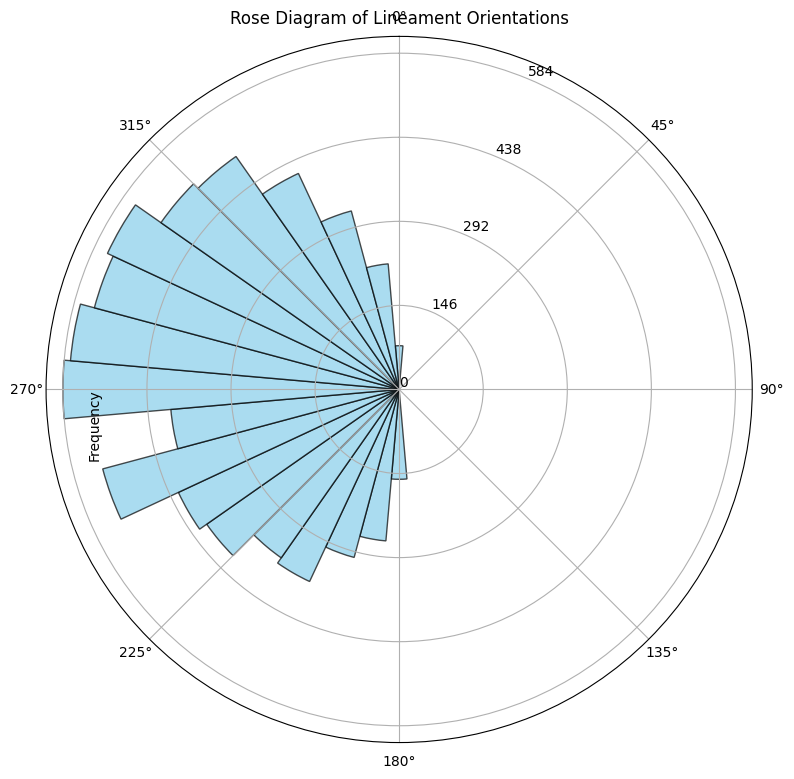

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get the orientation data (azimuths in degrees)
orientations_deg = gdf['Orient'].values

# Convert degrees to radians for plotting
orientations_rad = np.radians(orientations_deg)

# Normalize angles to be between 0 and 2*pi (0 to 360 degrees)
# This is important for a consistent rose diagram representation.
# Assuming 'Orient' gives values that can be negative, mapping them to 0-2*pi.
orientations_rad = np.where(orientations_rad < 0, orientations_rad + 2 * np.pi, orientations_rad)

# Create the rose diagram
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

# Calculate histogram bins for the rose diagram
# Let's use 36 bins, corresponding to 10-degree intervals across 360 degrees (2*pi radians)
bins = np.linspace(0, 2 * np.pi, 37) # 37 bin edges define 36 bins

# Create a histogram, 'n' are counts, 'bins' are edges
n, _ = np.histogram(orientations_rad, bins=bins)

# Plot the bars. For a polar bar plot, `theta` is the starting angle of the bar,
# `r` is the height, and `width` is the angular width of the bar.
# `bins[:-1]` provides the starting angles for each of the 36 bins.
# `n` provides the heights (counts) for each of the 36 bins.
# `np.diff(bins)` provides the width of each of the 36 bins.
ax.bar(bins[:-1], n, width=np.diff(bins), edgecolor='black', alpha=0.7, color='skyblue')

# Set the title and labels
ax.set_title('Rose Diagram of Lineament Orientations', va='bottom')
ax.set_theta_zero_location('N') # Set 0 degrees to North
ax.set_theta_direction(-1)     # Set clockwise direction

# Customize r-axis (frequency) labels
ax.set_yticks(np.linspace(0, n.max(), 5)) # Example: 5 ticks from 0 to max count
ax.set_yticklabels(np.round(np.linspace(0, n.max(), 5), 0).astype(int))
ax.set_ylabel('Frequency', labelpad=-40, y=0.45)

# Show the plot
plt.tight_layout()
plt.show()

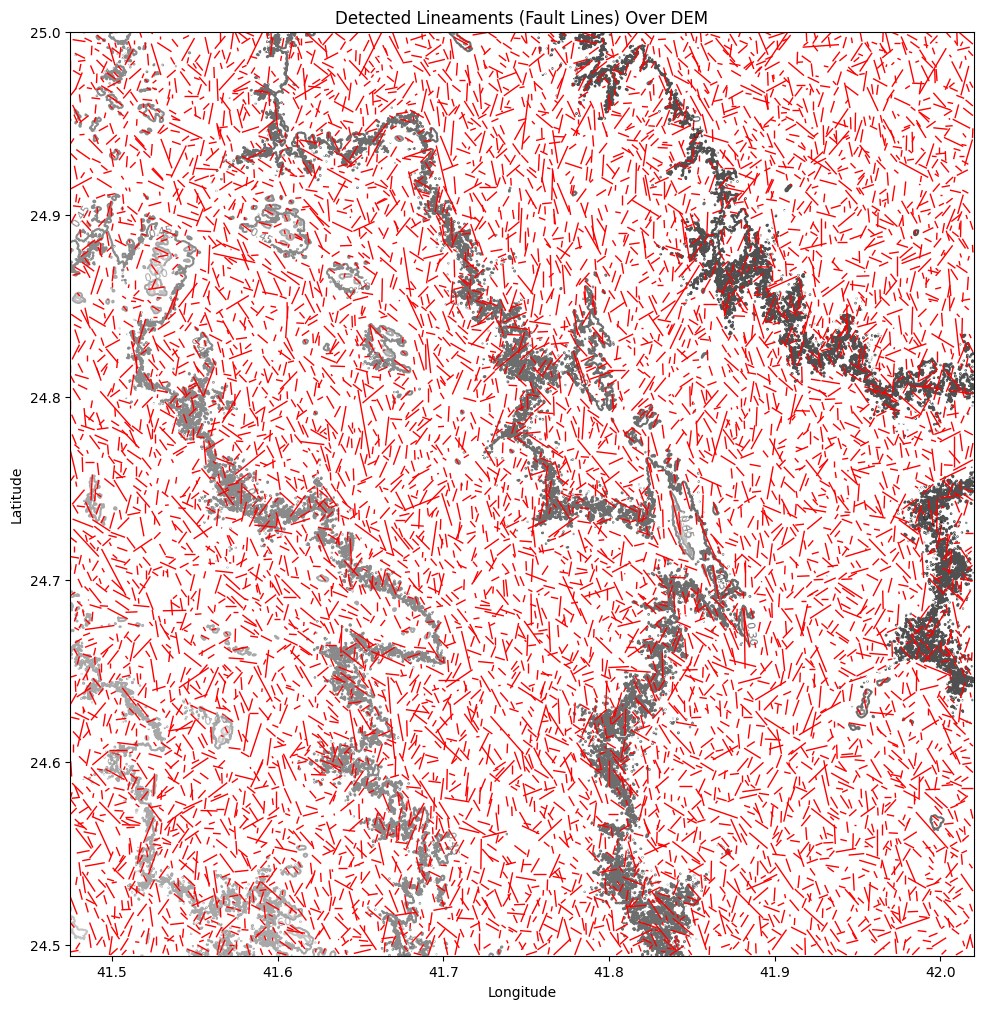

In [ ]:
import matplotlib.pyplot as plt
import rasterio.plot

# Re-open the DEM for plotting
with rasterio.open(dem_path) as src:
    dem_plot = src.read(1)
    transform_plot = src.transform

# Create a figure and axes
fig, ax = plt.subplots(figsize=(12, 12))

# Plot the DEM as a grayscale image
rasterio.plot.show(dem_plot, ax=ax, transform=transform_plot, cmap='gray', contour=True)

# Overlay the detected lineaments (fault lines)
gdf.plot(ax=ax, color='red', linewidth=1)

ax.set_title('Detected Lineaments (Fault Lines) Over DEM')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

In [ ]:
from google.colab import files

# Download the Shapefile
files.download('lineaments.shp')
files.download('lineaments.dbf') # Shapefiles often come with a .dbf file for attributes
files.download('lineaments.shx') # And a .shx file for spatial index
files.download('lineaments.prj') # And a .prj file for projection information

# Download the GeoPackage
files.download('lineaments.gpkg')

# Download the GeoJSON
files.download('lineaments.geojson')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>